## sst_trends in obs and lens

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import numpy as np
import os
import xarray as xr
import xcdat as xc
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm as BM
import pandas as pd
import matplotlib as mpl
import matplotlib.ticker as mticker
import netCDF4
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.util import add_cyclic_point
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

In [3]:
mpl.rcParams['font.family'] = 'Droid Sans'
mpl.rcParams['font.size'] = 12
# Edit axes parameters
mpl.rcParams['axes.linewidth'] = 1.5
# Tick properties
mpl.rcParams['xtick.major.size'] = 5
mpl.rcParams['xtick.minor.size'] = 3
mpl.rcParams['xtick.major.width'] = 1
mpl.rcParams['xtick.direction'] = 'out'
mpl.rcParams['ytick.major.size'] = 5
mpl.rcParams['ytick.minor.size'] = 3
mpl.rcParams['ytick.major.width'] = 1
mpl.rcParams['ytick.direction'] = 'out'

### Functions needed for the analysis

In [4]:
from functions.preproc_funcs import calc_anom, detrend_separate_check, get_corr, get_regr, detrend_dim

In [5]:
from functions import xr_lowess

In [6]:
# tas = (xr.open_dataset('/g/data/lp01/CMIP6/CMIP/MIROC/MIROC6/historical/r1i1p1f1/Amon/tas/gr1.5/v20181212/tas_Amon_MIROC6_historical_r1i1p1f1_gr1.5_185001-201412.nc').tas).load()
# # tas_ssp119 = (xr.open_dataset('/g/data/lp01/CMIP6/ScenarioMIP/MIROC/MIROC6/ssp119/r1i1p1f1/Amon/tas/gr1.5/v20190807/tas_Amon_MIROC6_ssp119_r1i1p1f1_gr1.5_201501-210012.nc').tas).load()
# tas_ssp1 = (xr.open_dataset('/g/data/lp01/CMIP6/ScenarioMIP/MIROC/MIROC6/ssp126/r1i1p1f1/Amon/tas/gr1.5/v20190627/tas_Amon_MIROC6_ssp126_r1i1p1f1_gr1.5_201501-210012.nc').tas).load()
# # tas_ssp2 = (xr.open_dataset('/g/data/lp01/CMIP6/ScenarioMIP/MIROC/MIROC6/ssp245/r1i1p1f1/Amon/tas/gr1.5/v20190627/tas_Amon_MIROC6_ssp245_r1i1p1f1_gr1.5_201501-210012.nc').tas).load()
# # tas_ssp3 = (xr.open_dataset('/g/data/lp01/CMIP6/ScenarioMIP/MIROC/MIROC6/ssp370/r1i1p1f1/Amon/tas/gr1.5/v20190627/tas_Amon_MIROC6_ssp370_r1i1p1f1_gr1.5_201501-210012.nc').tas).load()
# # tas_ssp4 = (xr.open_dataset('/g/data/lp01/CMIP6/ScenarioMIP/MIROC/MIROC6/ssp434/r1i1p1f1/Amon/tas/gr1.5/v20190807/tas_Amon_MIROC6_ssp434_r1i1p1f1_gr1.5_201501-210012.nc').tas).load()
# tas_ssp534_over = (xr.open_dataset('/g/data/lp01/CMIP6/ScenarioMIP/MIROC/MIROC6/ssp534-over/r1i1p1f1/Amon/tas/gr1.5/v20190807/tas_Amon_MIROC6_ssp534-over_r1i1p1f1_gr1.5_204001-210012.nc').tas).load()
# tas_ssp5 = (xr.open_dataset('/g/data/lp01/CMIP6/ScenarioMIP/MIROC/MIROC6/ssp585/r1i1p1f1/Amon/tas/gr1.5/v20190627/tas_Amon_MIROC6_ssp585_r1i1p1f1_gr1.5_201501-210012.nc').tas).load()

In [7]:
# weights = np.cos(np.deg2rad(tas.lat))
# weights.name = 'weights'
# tas_mean = tas.weighted(weights).mean(('lat', 'lon'))
# # tas_ssp119_mean = tas_ssp119.weighted(weights).mean(('lat', 'lon'))
# tas_ssp1_mean = tas_ssp1.weighted(weights).mean(('lat', 'lon'))
# # tas_ssp2_mean = tas_ssp2.weighted(weights).mean(('lat', 'lon'))
# # tas_ssp3_mean = tas_ssp3.weighted(weights).mean(('lat', 'lon'))
# # tas_ssp4_mean = tas_ssp4.weighted(weights).mean(('lat', 'lon'))
# tas_ssp534_over_mean = tas_ssp534_over.weighted(weights).mean(('lat', 'lon'))
# tas_ssp5_mean = tas_ssp5.weighted(weights).mean(('lat', 'lon'))

In [8]:
# # plt.figure(figsize=(10,5))
# # calc_anom(tas, tas.sel(time = slice('1850', '1900'))).sel(time = slice('2070', '2100')).mean('time').plot()
# # calc_anom(tas_ssp119_mean, tas_mean.sel(time = slice('1850', '1900'))).groupby('time.year').mean('time').plot()
# calc_anom(tas_ssp1_mean, tas_mean.sel(time = slice('1850', '1900'))).plot()
# # calc_anom(tas_ssp2_mean, tas_mean.sel(time = slice('1850', '1900'))).groupby('time.year').mean('time').plot()
# # calc_anom(tas_ssp3_mean, tas_mean.sel(time = slice('1850', '1900'))).groupby('time.year').mean('time').plot()
# # calc_anom(tas_ssp4_mean, tas_mean.sel(time = slice('1850', '1900'))).groupby('time.year').mean('time').plot()
# calc_anom(tas_ssp534_over_mean, tas_mean.sel(time = slice('1850', '1900'))).plot()
# calc_anom(tas_ssp5_mean, tas_mean.sel(time = slice('1850', '1900'))).sel(time = slice('2014', '2041')).plot()
# calc_anom(tas_ssp5_mean, tas_mean.sel(time = slice('1850', '1900'))).plot()

In [9]:
from functions.preproc_funcs import calc_trend3d, calc_trend_pval3d

In [10]:
obs_sst = xr.open_dataset('../seasonal_period_analysis/data/obs/ersst_v5.nc').sst.resample(time = '1Y').mean('time')
obs_sst_anom = calc_anom(obs_sst, obs_sst.sel(time = slice('1960', '1990')))

In [11]:
obs_trend = calc_trend3d(obs_sst.sel(time = slice('1980', '2020')), 'time')

In [12]:
obs_trend1 = calc_trend3d(obs_sst.sel(time = slice('1980', '1990')), 'time')

In [13]:
obs_trend2 = calc_trend3d(obs_sst.sel(time = slice('2010', '2020')), 'time')

In [14]:
from matplotlib import patches as mpatches

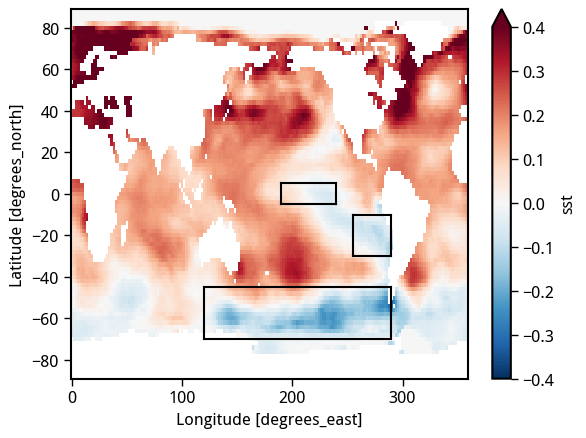

In [15]:
obs_trend.plot(vmin=-0.4)
plt.plot([120, 290], [-70, -70], color='k')
plt.plot([120, 290], [-45, -45], color='k')
plt.plot([120, 120], [-70, -45], color='k')
plt.plot([290, 290], [-70, -45], color='k')

plt.plot([-170+360, -120+360], [-5, -5], color='k')
plt.plot([-170+360, -120+360], [5, 5], color='k')
plt.plot([-170+360, -170+360], [-5, 5], color='k')
plt.plot([-120+360, -120+360], [-5, 5], color='k')

plt.plot([-105+360, -70+360], [-30, -30], color='k')
plt.plot([-105+360, -70+360], [-10, -10], color='k')
plt.plot([-105+360, -105+360], [-30, -10], color='k')
plt.plot([-70+360, -70+360], [-30, -10], color='k')

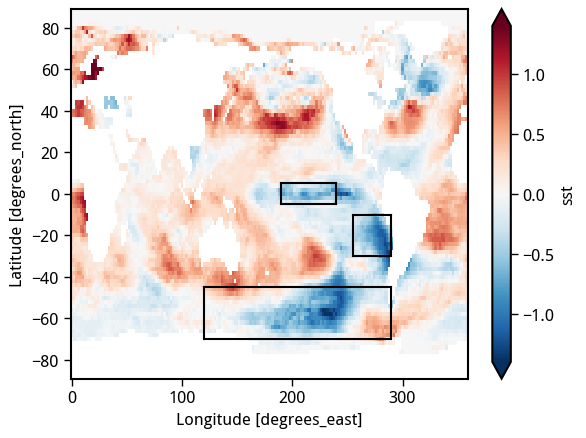

In [16]:
obs_trend1.plot(vmin=-1.4)
plt.plot([120, 290], [-70, -70], color='k')
plt.plot([120, 290], [-45, -45], color='k')
plt.plot([120, 120], [-70, -45], color='k')
plt.plot([290, 290], [-70, -45], color='k')

plt.plot([-170+360, -120+360], [-5, -5], color='k')
plt.plot([-170+360, -120+360], [5, 5], color='k')
plt.plot([-170+360, -170+360], [-5, 5], color='k')
plt.plot([-120+360, -120+360], [-5, 5], color='k')

plt.plot([-105+360, -70+360], [-30, -30], color='k')
plt.plot([-105+360, -70+360], [-10, -10], color='k')
plt.plot([-105+360, -105+360], [-30, -10], color='k')
plt.plot([-70+360, -70+360], [-30, -10], color='k')

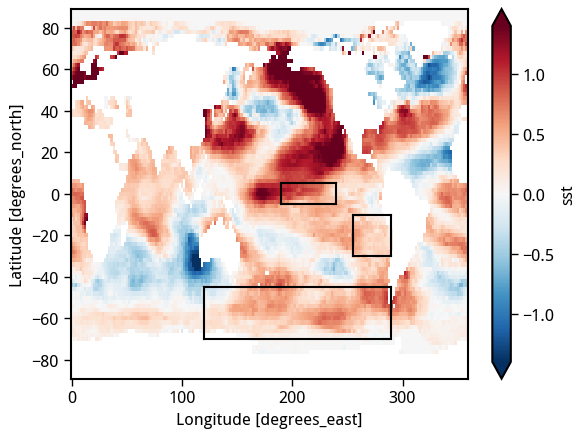

In [17]:
obs_trend2.plot(vmin=-1.4)
plt.plot([120, 290], [-70, -70], color='k')
plt.plot([120, 290], [-45, -45], color='k')
plt.plot([120, 120], [-70, -45], color='k')
plt.plot([290, 290], [-70, -45], color='k')

plt.plot([-170+360, -120+360], [-5, -5], color='k')
plt.plot([-170+360, -120+360], [5, 5], color='k')
plt.plot([-170+360, -170+360], [-5, 5], color='k')
plt.plot([-120+360, -120+360], [-5, 5], color='k')

plt.plot([-105+360, -70+360], [-30, -30], color='k')
plt.plot([-105+360, -70+360], [-10, -10], color='k')
plt.plot([-105+360, -105+360], [-30, -10], color='k')
plt.plot([-70+360, -70+360], [-30, -10], color='k')

In [18]:
north_mar = pd.read_csv('./data/N_03_extent_v3.0.csv')

north_sep = pd.read_csv('./data/N_09_extent_v3.0.csv')
south_mar = pd.read_csv('./data/S_03_extent_v3.0.csv')
south_sep = pd.read_csv('./data/S_09_extent_v3.0.csv')

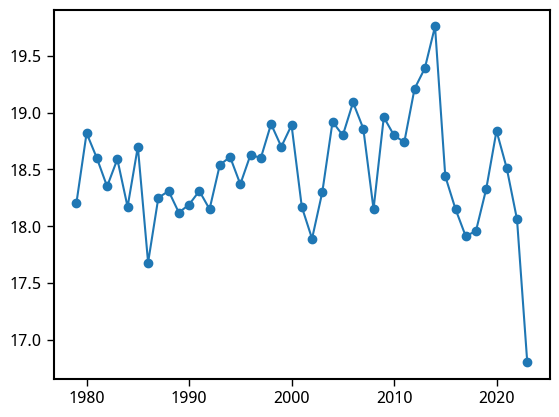

In [19]:
plt.plot(south_sep['year'], south_sep[' extent'], marker='o')
# plt.plot(south_mar['year'], south_mar[' extent'], marker='o')

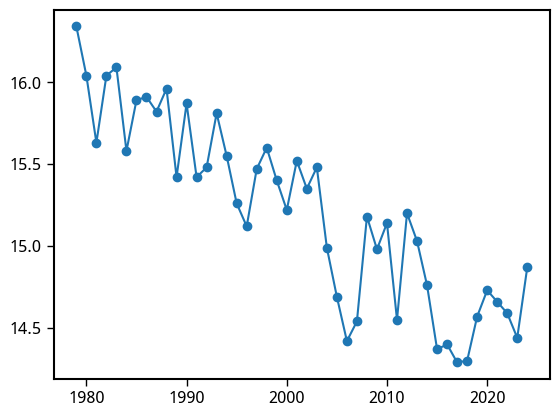

In [20]:
plt.plot(north_mar['year'], north_mar[' extent'], marker='o')

In [21]:
import pymannkendall as mk

In [22]:
mk.hamed_rao_modification_test(south_sep.where((south_sep['year'] > 1979) & (south_sep['year'] < 2021)).dropna()[' extent'])

Modified_Mann_Kendall_Test_Hamed_Rao_Approach(trend='no trend', h=False, p=0.2183728998172798, z=1.2308662298583473, Tau=0.17560975609756097, s=144.0, var_s=13497.407563525112, slope=0.009318181818181902, intercept=18.403636363636362)

In [23]:
mk.hamed_rao_modification_test(south_sep.where((south_sep['year'] > 1979) & (south_sep['year'] < 2011)).dropna()[' extent'])

Modified_Mann_Kendall_Test_Hamed_Rao_Approach(trend='increasing', h=True, p=0.04471585979174031, z=2.007317567290854, Tau=0.25591397849462366, s=119.0, var_s=3455.6666666666665, slope=0.01538461538461533, intercept=18.35923076923077)

In [24]:
mk.hamed_rao_modification_test(south_sep.where((south_sep['year'] > 2010) & (south_sep['year'] < 2024)).dropna()[' extent'])

Modified_Mann_Kendall_Test_Hamed_Rao_Approach(trend='decreasing', h=True, p=0.0036644241510872533, z=-2.905691606976865, Tau=-0.41025641025641024, s=-32.0, var_s=113.82151182151185, slope=-0.12185714285714302, intercept=19.17114285714286)

In [25]:
# plt.plot([120, 290], [-70, -70], color='k')
# plt.plot([120, 290], [-45, -45], color='k')
# plt.plot([120, 120], [-70, -45], color='k')
# plt.plot([290, 290], [-70, -45], color='k')

# plt.plot([-170+360, -120+360], [-5, -5], color='k')
# plt.plot([-170+360, -120+360], [5, 5], color='k')
# plt.plot([-170+360, -170+360], [-5, 5], color='k')
# plt.plot([-120+360, -120+360], [-5, 5], color='k')

# plt.plot([-105+360, -70+360], [-30, -30], color='k')
# plt.plot([-105+360, -70+360], [-10, -10], color='k')
# plt.plot([-105+360, -105+360], [-30, -10], color='k')
# plt.plot([-70+360, -70+360], [-30, -10], color='k')

In [26]:
def sst_sector_trends_obs(obs_sst):
    out = np.empty((3))
    out_pval = np.empty((3))
    weights=np.cos(np.deg2rad(obs_sst.lat))
    sst_n34 = obs_sst.sel(lon = slice(-170+360, -120+360), lat = slice(5, -5)).weighted(weights).mean(('lat', 'lon'))
    sst_so = obs_sst.sel(lon = slice(120, 290), lat = slice(-45, -70)).weighted(weights).mean(('lat', 'lon'))
    sst_epsa = obs_sst.sel(lon = slice(-105+360, -70+360), lat = slice(-10, -30)).weighted(weights).mean(('lat', 'lon'))
    val_list = [sst_n34, sst_so, sst_epsa]
    for j in range(len(val_list)):
        val_anom = calc_anom(val_list[j], val_list[j].sel(time = slice('1960', '1990')))
        val_trend = calc_trend3d(val_anom.sel(time = slice('1980', '2015')), 'time')
        val_pval = calc_trend_pval3d(val_anom.sel(time = slice('1980', '2015')), 'time')
        out[j] = float(val_trend)
        out_pval[j] = val_pval
    return out, out_pval

In [27]:
out_obs, out_obs_pval = sst_sector_trends_obs(obs_sst)
out_obs, out_obs_pval

(array([-0.04203614, -0.10798246, -0.09869153]),
 array([6.77248987e-01, 1.35022859e-04, 1.16868208e-02]))

In [41]:
def sst_sector_trends_lens(lens_n, model_name):
    out = np.empty((lens_n, 3))
    out_pval = np.empty((lens_n, 3))
    for i in range(lens_n):
        sst = xr.open_mfdataset(f'/g/data/v45/nxm561/{model_name}_lens/Omon/tos/tos_*hist_*r{i+1}i1*.nc').tos.resample(time='1Y').mean('time').load()
        weights=np.cos(np.deg2rad(sst.lat))
        sst_n34 = sst.sel(lon = slice(-170+360, -120+360), lat = slice(-5, 5)).weighted(weights).mean(('lat', 'lon'))
        sst_so = sst.sel(lon = slice(120, 290), lat = slice(-70, -45)).weighted(weights).mean(('lat', 'lon'))
        sst_epsa = sst.sel(lon = slice(-105+360, -70+360), lat = slice(-30, -10)).weighted(weights).mean(('lat', 'lon'))
        val_list = [sst_n34, sst_so, sst_epsa]
        for j in range(len(val_list)):
            val_anom = calc_anom(val_list[j], val_list[j].sel(time = slice('1960', '1990')))
            val_trend = calc_trend3d(val_anom.sel(time = slice('1980', '2020')), 'time')
            val_pval = calc_trend_pval3d(val_anom.sel(time = slice('1980', '2020')), 'time')
            out[i, j] = float(val_trend)
            out_pval[i, j] = val_pval
            print(f'Completed {i+1} - {j+1}', end='\r')
    return out, out_pval

In [42]:
def create_res_dataframe(trend_arr, pval_arr):
    out_df = pd.DataFrame(dict(n34_trend = trend_arr[:,0], n34_pval = pval_arr[:,0],
                               so_trend = trend_arr[:,1], so_pval = pval_arr[:,1],
                               epsa_trend = trend_arr[:,2], epsa_pval = pval_arr[:,2]))
    return out_df

In [43]:
# access_trend, access_pval = sst_sector_trends_lens(40, model_name='access')

In [44]:
# access_cmip6_df = create_res_dataframe(access_trend, access_pval)

In [45]:
# access_cmip6_df.to_csv('./data/res_trends/access.csv')

In [33]:
from scipy import stats

In [47]:
access_df = pd.read_csv('./data/res_trends/access.csv')
miroc6_df = pd.read_csv('./data/res_trends/miroc6.csv')
miroc_esm2l_df = pd.read_csv('./data/res_trends/miroc_esm2l.csv')
mpi_df = pd.read_csv('./data/res_trends/mpi.csv')
mpi_cmip6_df = pd.read_csv('./data/res_trends/mpi_cmip6.csv')
ipsl_cm6a_df = pd.read_csv('./data/res_trends/ipsl_cm6a.csv')
gfdl_spear_df = pd.read_csv('./data/res_trends/gfdl_spear.csv')
csiro_mk36_df = pd.read_csv('./data/res_trends/csiro_mk36.csv')
cesm1_df = pd.read_csv('./data/res_trends/cesm1.csv')
canesm2_df = pd.read_csv('./data/res_trends/canesm2.csv')
canesm5_df = pd.read_csv('./data/res_trends/canesm5.csv')

In [55]:
combined_lens = pd.concat([access_df, miroc6_df, miroc_esm2l_df, mpi_df, mpi_cmip6_df, ipsl_cm6a_df, gfdl_spear_df, csiro_mk36_df, cesm1_df, canesm2_df, canesm5_df])

In [56]:
import seaborn as sns

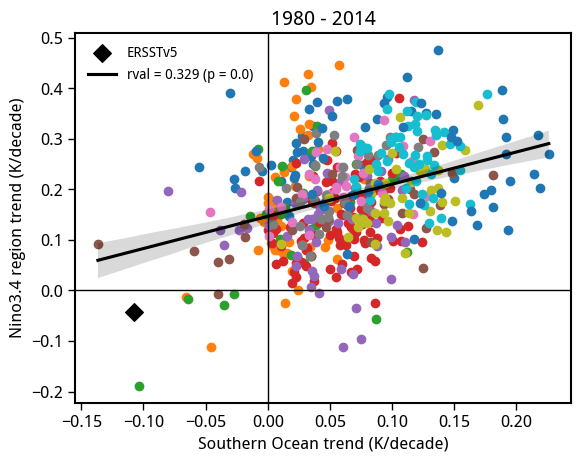

In [57]:
plt.axhline(0.0, color='k', lw=1.0)
plt.axvline(0.0, color='k', lw=1.0)
plt.scatter(access_df['so_trend'], access_df['n34_trend'])
plt.scatter(miroc6_df['so_trend'], miroc6_df['n34_trend'])
plt.scatter(miroc_esm2l_df['so_trend'], miroc_esm2l_df['n34_trend'])
plt.scatter(mpi_df['so_trend'], mpi_df['n34_trend'])
plt.scatter(mpi_cmip6_df['so_trend'], mpi_cmip6_df['n34_trend'])
plt.scatter(ipsl_cm6a_df['so_trend'], ipsl_cm6a_df['n34_trend'])
plt.scatter(gfdl_spear_df['so_trend'], gfdl_spear_df['n34_trend'])
plt.scatter(csiro_mk36_df['so_trend'], csiro_mk36_df['n34_trend'])
plt.scatter(cesm1_df['so_trend'], cesm1_df['n34_trend'])
plt.scatter(canesm2_df['so_trend'], canesm2_df['n34_trend'])
plt.scatter(canesm5_df['so_trend'], canesm5_df['n34_trend'])
plt.scatter(out_obs[1], out_obs[0], color='k', marker='D', s=80, label='ERSSTv5')

res = stats.spearmanr(combined_lens['so_trend'], combined_lens['n34_trend'])
sns.regplot(x = combined_lens['so_trend'], y=combined_lens['n34_trend'], scatter=False, color='k', label = f'rval = {np.round(res.statistic, 3)} (p = {np.round(res.pvalue, 3)})')
plt.xlabel('Southern Ocean trend (K/decade)')
plt.ylabel('Nino3.4 region trend (K/decade)')
plt.title('1980 - 2014')
plt.legend(frameon=False, fontsize=10)

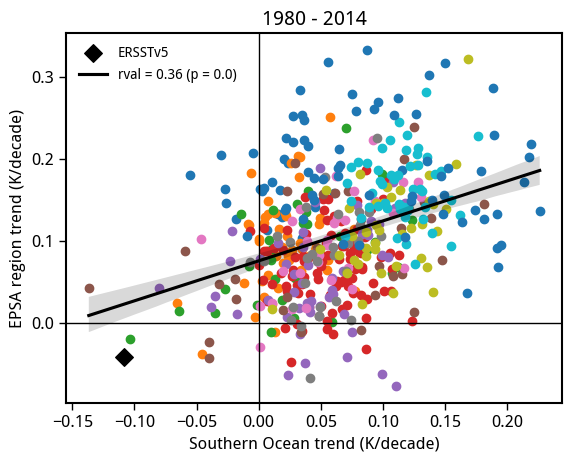

In [61]:
plt.axhline(0.0, color='k', lw=1.0)
plt.axvline(0.0, color='k', lw=1.0)
plt.scatter(access_df['so_trend'], access_df['epsa_trend'])
plt.scatter(miroc6_df['so_trend'], miroc6_df['epsa_trend'])
plt.scatter(miroc_esm2l_df['so_trend'], miroc_esm2l_df['epsa_trend'])
plt.scatter(mpi_df['so_trend'], mpi_df['epsa_trend'])
plt.scatter(mpi_cmip6_df['so_trend'], mpi_cmip6_df['epsa_trend'])
plt.scatter(ipsl_cm6a_df['so_trend'], ipsl_cm6a_df['epsa_trend'])
plt.scatter(gfdl_spear_df['so_trend'], gfdl_spear_df['epsa_trend'])
plt.scatter(csiro_mk36_df['so_trend'], csiro_mk36_df['epsa_trend'])
plt.scatter(cesm1_df['so_trend'], cesm1_df['epsa_trend'])
plt.scatter(canesm2_df['so_trend'], canesm2_df['epsa_trend'])
plt.scatter(canesm5_df['so_trend'], canesm5_df['epsa_trend'])
plt.scatter(out_obs[1], out_obs[0], color='k', marker='D', s=80, label='ERSSTv5')

res = stats.spearmanr(combined_lens['so_trend'], combined_lens['epsa_trend'])
sns.regplot(x = combined_lens['so_trend'], y=combined_lens['epsa_trend'], scatter=False, color='k', label = f'rval = {np.round(res.statistic, 3)} (p = {np.round(res.pvalue, 3)})')
plt.xlabel('Southern Ocean trend (K/decade)')
plt.ylabel('EPSA region trend (K/decade)')
plt.title('1980 - 2014')
plt.legend(frameon=False, fontsize=10)

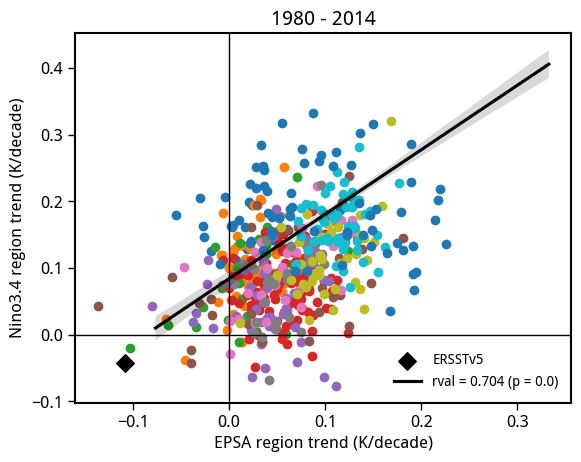

In [62]:
plt.axhline(0.0, color='k', lw=1.0)
plt.axvline(0.0, color='k', lw=1.0)
plt.scatter(access_df['so_trend'], access_df['epsa_trend'])
plt.scatter(miroc6_df['so_trend'], miroc6_df['epsa_trend'])
plt.scatter(miroc_esm2l_df['so_trend'], miroc_esm2l_df['epsa_trend'])
plt.scatter(mpi_df['so_trend'], mpi_df['epsa_trend'])
plt.scatter(mpi_cmip6_df['so_trend'], mpi_cmip6_df['epsa_trend'])
plt.scatter(ipsl_cm6a_df['so_trend'], ipsl_cm6a_df['epsa_trend'])
plt.scatter(gfdl_spear_df['so_trend'], gfdl_spear_df['epsa_trend'])
plt.scatter(csiro_mk36_df['so_trend'], csiro_mk36_df['epsa_trend'])
plt.scatter(cesm1_df['so_trend'], cesm1_df['epsa_trend'])
plt.scatter(canesm2_df['so_trend'], canesm2_df['epsa_trend'])
plt.scatter(canesm5_df['so_trend'], canesm5_df['epsa_trend'])
plt.scatter(out_obs[1], out_obs[0], color='k', marker='D', s=80, label='ERSSTv5')

res = stats.spearmanr(combined_lens['epsa_trend'], combined_lens['n34_trend'])
sns.regplot(x = combined_lens['epsa_trend'], y=combined_lens['n34_trend'], scatter=False, color='k', label = f'rval = {np.round(res.statistic, 3)} (p = {np.round(res.pvalue, 3)})')
plt.xlabel('EPSA region trend (K/decade)')
plt.ylabel('Nino3.4 region trend (K/decade)')
plt.title('1980 - 2014')
plt.legend(frameon=False, fontsize=10)